In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data.csv")
df["date"] = pd.to_datetime(df["date"])
display(df.head())
df.info(verbose=True, show_counts=True)

,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,...,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
0,Adrian Yanez,Gustavo Lopez,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Bantamweight,0.000,0.0,...,0,1,0,0,Orthodox,170.18,177.80,135.0,31.0,27.0
1,Trevin Giles,Roman Dolidze,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Middleweight,0.500,0.0,...,0,3,0,0,Orthodox,182.88,187.96,185.0,32.0,28.0
2,Tai Tuivasa,Harry Hunsucker,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Heavyweight,NaN,NaN,...,1,3,0,0,Southpaw,187.96,190.50,264.0,32.0,28.0
3,Cheyanne Buys,Montserrat Conejo,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenStrawweight,NaN,NaN,...,0,0,0,0,Switch,160.02,160.02,115.0,28.0,25.0
4,Marion Reneau,Macy Chiasson,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenBantamweight,0.125,0.0,...,1,2,2,0,Orthodox,167.64,172.72,135.0,29.0,43.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6012 entries, 0 to 6011
Data columns (total 144 columns):
 #    Column                        Non-Null Count  Dtype         
---   ------                        --------------  -----         
 0    R_fighter                     6012 non-null   object        
 1    B_fighter                     6012 non-null   object        
 2    Referee                       5980 non-null   object        
 3    date                          6012 non-null   datetime64[ns]
 4    location                      6012 non-null   object        
 5    Winner                        6012 non-null   object        
 6    title_bout                    6012 non-null   bool          
 7    weight_class                  6012 non-null   object        
 8    B_avg_KD                      4585 non-null   float64       
 9    B_avg_opp_KD                  4585 non-null   float64       
 10   B_avg_SIG_STR_pct             4585 non-null   float64       
 11   B_avg_opp_SIG_S

In [3]:
# new dataframe without the missing values.
new_df = df.dropna().copy()
display(new_df.head())
new_df.info(verbose=True, show_counts=True)

,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,...,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
0,Adrian Yanez,Gustavo Lopez,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Bantamweight,0.000000,0.000,...,0,1,0,0,Orthodox,170.18,177.80,135.0,31.0,27.0
1,Trevin Giles,Roman Dolidze,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Middleweight,0.500000,0.000,...,0,3,0,0,Orthodox,182.88,187.96,185.0,32.0,28.0
4,Marion Reneau,Macy Chiasson,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenBantamweight,0.125000,0.000,...,1,2,2,0,Orthodox,167.64,172.72,135.0,29.0,43.0
5,Leonardo Santos,Grant Dawson,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,Lightweight,0.000000,0.000,...,2,2,2,0,Orthodox,182.88,190.50,155.0,27.0,41.0
6,Song Kenan,Max Griffin,Keith Peterson,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,Welterweight,0.046875,0.125,...,1,3,0,0,Orthodox,182.88,180.34,170.0,35.0,31.0


<class 'pandas.core.frame.DataFrame'>
Index: 3890 entries, 0 to 5884
Data columns (total 144 columns):
 #    Column                        Non-Null Count  Dtype         
---   ------                        --------------  -----         
 0    R_fighter                     3890 non-null   object        
 1    B_fighter                     3890 non-null   object        
 2    Referee                       3890 non-null   object        
 3    date                          3890 non-null   datetime64[ns]
 4    location                      3890 non-null   object        
 5    Winner                        3890 non-null   object        
 6    title_bout                    3890 non-null   bool          
 7    weight_class                  3890 non-null   object        
 8    B_avg_KD                      3890 non-null   float64       
 9    B_avg_opp_KD                  3890 non-null   float64       
 10   B_avg_SIG_STR_pct             3890 non-null   float64       
 11   B_avg_opp_SIG_STR_pc

,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,...,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
1283,Demetrious Johnson,Henry Cejudo,Mike Beltran,2018-08-04,"Los Angeles, California, USA",Blue,True,Flyweight,0.382812,0.062500,...,7,2,5,0,Orthodox,160.02,167.64,125.0,31.0,31.0
1697,Demetrious Johnson,Ray Borg,Dan Miragliotta,2017-10-07,"Las Vegas, Nevada, USA",Red,True,Flyweight,0.000000,0.000000,...,7,2,4,0,Orthodox,160.02,167.64,125.0,24.0,31.0
1902,Demetrious Johnson,Wilson Reis,Dan Miragliotta,2017-04-15,"Kansas City, Missouri, USA",Red,True,Flyweight,0.000000,0.117188,...,7,2,3,0,Orthodox,160.02,167.64,125.0,32.0,30.0
2069,Demetrious Johnson,Tim Elliott,Herb Dean,2016-12-03,"Las Vegas, Nevada, USA",Red,True,Flyweight,0.031250,0.000000,...,6,2,3,0,Orthodox,160.02,167.64,125.0,29.0,30.0
2382,Demetrious Johnson,Henry Cejudo,John McCarthy,2016-04-23,"Las Vegas, Nevada, USA",Red,True,Flyweight,0.125000,0.000000,...,6,1,3,0,Orthodox,160.02,167.64,125.0,29.0,29.0
2645,Demetrious Johnson,John Dodson,Herb Dean,2015-09-05,"Las Vegas, Nevada, USA",Red,True,Flyweight,0.640625,0.000000,...,5,1,3,0,Orthodox,160.02,167.64,125.0,30.0,29.0
2838,Demetrious Johnson,Kyoji Horiguchi,Yves Lavigne,2015-04-25,"Montreal, Quebec, Canada",Red,True,Flyweight,0.250000,0.000000,...,5,1,2,0,Orthodox,160.02,167.64,125.0,24.0,28.0
3114,Demetrious Johnson,Chris Cariaso,Herb Dean,2014-09-27,"Las Vegas, Nevada, USA",Red,True,Flyweight,0.000000,0.000000,...,5,1,1,0,Orthodox,160.02,167.64,125.0,33.0,28.0
3267,Demetrious Johnson,Ali Bagautinov,Jerin Valel,2014-06-14,"Vancouver, British Columbia, Canada",Red,True,Flyweight,0.500000,0.000000,...,4,1,1,0,Orthodox,160.02,167.64,125.0,29.0,27.0
3499,Demetrious Johnson,Joseph Benavidez,John McCarthy,2013-12-14,"Sacramento, California, USA",Red,True,Flyweight,1.031250,0.000000,...,4,0,1,0,Orthodox,160.02,167.64,125.0,29.0,27.0


R_fighter           Demetrious Johnson
B_fighter                 Henry Cejudo
Referee                  John McCarthy
date               2016-04-23 00:00:00
location        Las Vegas, Nevada, USA
                         ...          
R_Height_cms                    160.02
R_Reach_cms                     167.64
R_Weight_lbs                     125.0
B_age                             29.0
R_age                             29.0
Name: 2382, Length: 144, dtype: object

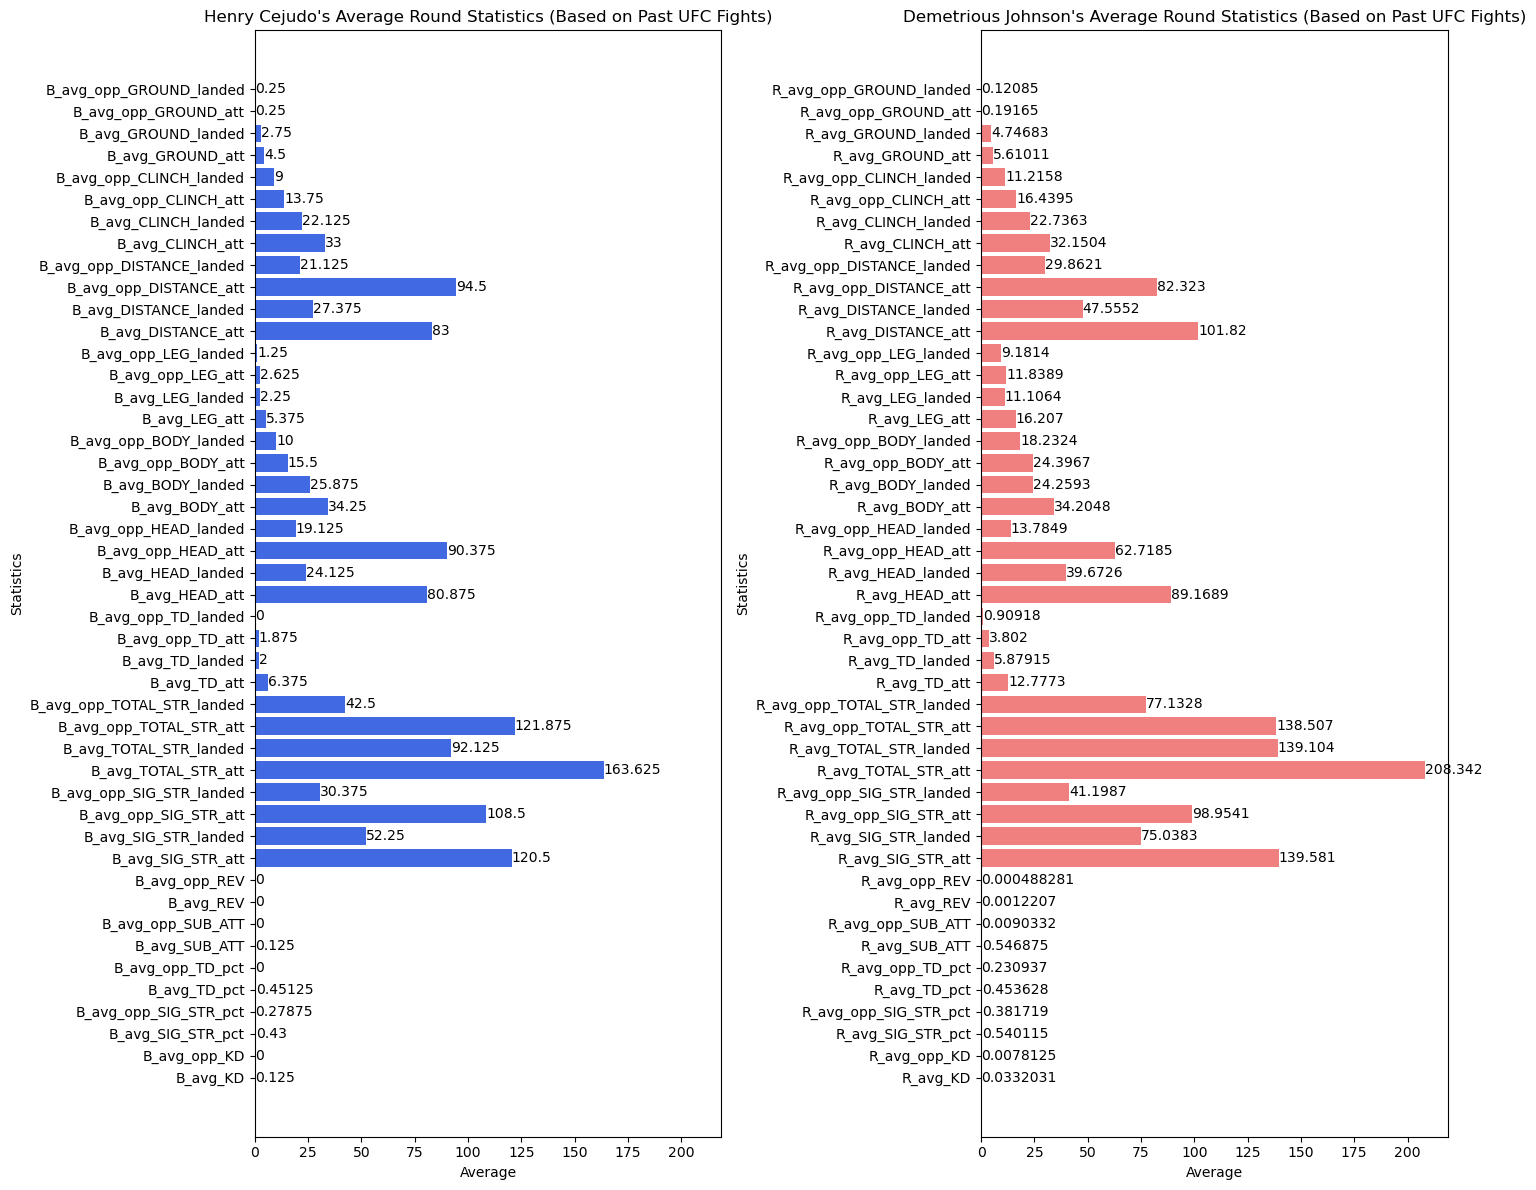

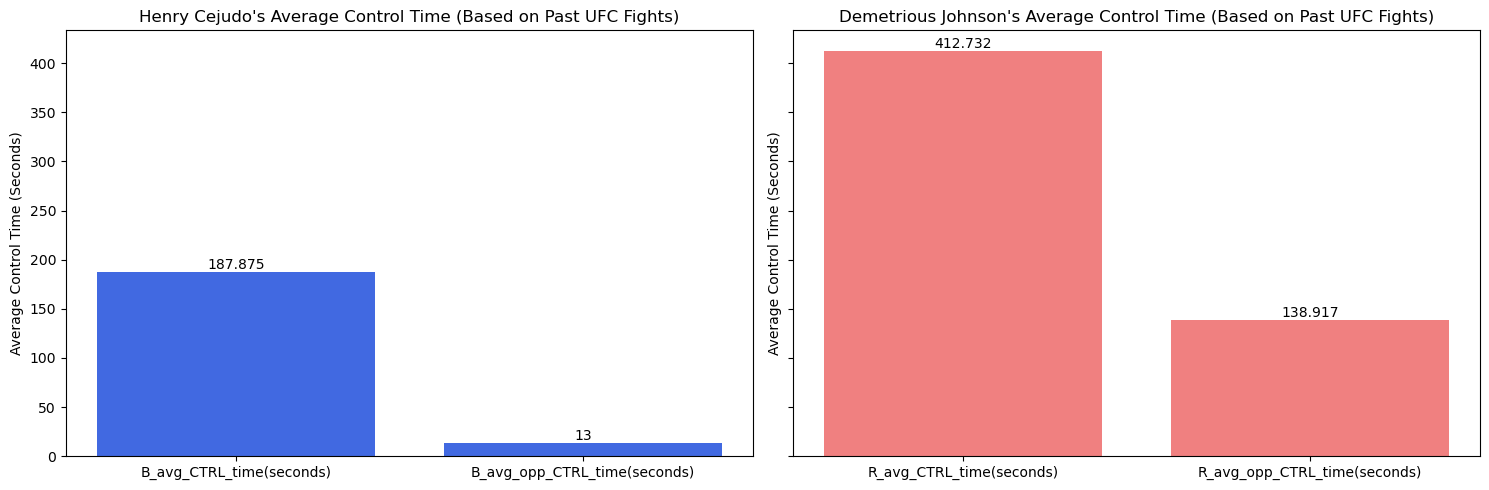

In [4]:
# One important question that I think can be answered through this dataset is how to identify a great fighter.
# To find an answer to this question, I think the best place to start is to observe the data of one of the best fighters of all time.
# How did Demetrious Johnson win so many fights in a row against some of the most skilled fighters in the world?
# Can we see the same pattern for other great fighters?
# If so, is it possible to accurately predict if a fighter will become one of the greatest fighters only based on statistics?
great_fighter_df = pd.concat([new_df[new_df["R_fighter"] == "Demetrious Johnson"], 
                             new_df[new_df["B_fighter"] == "Demetrious Johnson"]])
display(great_fighter_df)

DJ_HenryCejudo_df = great_fighter_df.iloc[4].copy()
display(DJ_HenryCejudo_df)

# Can see that it is difficult to see the values of other columns due to the avg_CTRL_time(seconds) values being too large.
# Will remove this column and compare it separately.
fig, axs = plt.subplots(1, 2, sharex=True, figsize=(15,12))

graph1 = axs[0].barh(DJ_HenryCejudo_df.loc["B_avg_KD":"B_avg_opp_GROUND_landed"].index, 
                     DJ_HenryCejudo_df.loc["B_avg_KD":"B_avg_opp_GROUND_landed"].values,
                     color = "royalblue")
axs[0].bar_label(graph1)
axs[0].set_xlabel("Average")
axs[0].set_ylabel("Statistics")
axs[0].set_title("Henry Cejudo's Average Round Statistics (Based on Past UFC Fights)")

graph2 = axs[1].barh(DJ_HenryCejudo_df.loc["R_avg_KD":"R_avg_opp_GROUND_landed"].index, 
                     DJ_HenryCejudo_df.loc["R_avg_KD":"R_avg_opp_GROUND_landed"].values,
                     color = "lightcoral")
axs[1].bar_label(graph2)
axs[1].set_xlabel("Average")
axs[1].set_ylabel("Statistics")
axs[1].set_title("Demetrious Johnson's Average Round Statistics (Based on Past UFC Fights)")

fig.tight_layout()



fig1, axs1 = plt.subplots(1, 2, sharey=True, figsize=(15,5))

graph3 = axs1[0].bar(["B_avg_CTRL_time(seconds)", "B_avg_opp_CTRL_time(seconds)"], 
                     DJ_HenryCejudo_df[["B_avg_CTRL_time(seconds)", "B_avg_opp_CTRL_time(seconds)"]],
                     color = "royalblue")
axs1[0].bar_label(graph3)
axs1[0].set_ylabel("Average Control Time (Seconds)")
axs1[0].set_title("Henry Cejudo's Average Control Time (Based on Past UFC Fights)")

graph4 = axs1[1].bar(["R_avg_CTRL_time(seconds)", "R_avg_opp_CTRL_time(seconds)"], 
                     DJ_HenryCejudo_df[["R_avg_CTRL_time(seconds)", "R_avg_opp_CTRL_time(seconds)"]],
                     color = "lightcoral")
axs1[1].bar_label(graph4)
axs1[1].set_ylabel("Average Control Time (Seconds)")
axs1[1].set_title("Demetrious Johnson's Average Control Time (Based on Past UFC Fights)")

fig1.tight_layout()
plt.show()

In [5]:
# This is just a quick check to see if the columns are in the same order.
# Making sure that I am not comparing the incorrect columns.
HenryCejudo_cols = DJ_HenryCejudo_df.loc["B_avg_KD":"B_avg_opp_CTRL_time(seconds)"].index.to_list()
DJ_cols = DJ_HenryCejudo_df.loc["R_avg_KD":"R_avg_opp_CTRL_time(seconds)"].index.to_list()
for col in range(len(HenryCejudo_cols)):
    HenryCejudo_cols[col] = HenryCejudo_cols[col][1:]
    DJ_cols[col] = DJ_cols[col][1:]

if HenryCejudo_cols == DJ_cols:
    print("The columns are in the same order.")




# Comparing the round statistics between the two fighters.
# Demetrious Johnson only has 10 column values/stats (48 in total) that is smaller compared Henry Cejudo.
print("\n\nAll column values where Demetrious Johnson's stats are smaller than Henry Cejudos:")
for i in range(len(DJ_HenryCejudo_df.loc["B_avg_KD":"B_avg_opp_CTRL_time(seconds)"].values)):
    if DJ_HenryCejudo_df.loc["R_avg_KD":"R_avg_opp_CTRL_time(seconds)"].values[i] < DJ_HenryCejudo_df.loc["B_avg_KD":"B_avg_opp_CTRL_time(seconds)"].values[i]:
        print(DJ_HenryCejudo_df.loc["R_avg_KD":"R_avg_opp_CTRL_time(seconds)"].index[i])

print("\n\nAll column values where Demetrious Johnson's stats are greater than Henry Cejudos:")
for i in range(len(DJ_HenryCejudo_df.loc["B_avg_KD":"B_avg_opp_CTRL_time(seconds)"].values)):
    if DJ_HenryCejudo_df.loc["R_avg_KD":"R_avg_opp_CTRL_time(seconds)"].values[i] > DJ_HenryCejudo_df.loc["B_avg_KD":"B_avg_opp_CTRL_time(seconds)"].values[i]:
        print(DJ_HenryCejudo_df.loc["R_avg_KD":"R_avg_opp_CTRL_time(seconds)"].index[i])

print("\n\nAll column values where Demetrious Johnson's stats are equal to Henry Cejudos:")
for i in range(len(DJ_HenryCejudo_df.loc["B_avg_KD":"B_avg_opp_CTRL_time(seconds)"].values)):
    if DJ_HenryCejudo_df.loc["R_avg_KD":"R_avg_opp_CTRL_time(seconds)"].values[i] == DJ_HenryCejudo_df.loc["B_avg_KD":"B_avg_opp_CTRL_time(seconds)"].values[i]:
        print(DJ_HenryCejudo_df.loc["R_avg_KD":"R_avg_opp_CTRL_time(seconds)"].index[i])

The columns are in the same order.


All column values where Demetrious Johnson's stats are smaller than Henry Cejudos:
R_avg_KD
R_avg_opp_SIG_STR_att
R_avg_opp_HEAD_att
R_avg_opp_HEAD_landed
R_avg_BODY_att
R_avg_BODY_landed
R_avg_opp_DISTANCE_att
R_avg_CLINCH_att
R_avg_opp_GROUND_att
R_avg_opp_GROUND_landed


All column values where Demetrious Johnson's stats are greater than Henry Cejudos:
R_avg_opp_KD
R_avg_SIG_STR_pct
R_avg_opp_SIG_STR_pct
R_avg_TD_pct
R_avg_opp_TD_pct
R_avg_SUB_ATT
R_avg_opp_SUB_ATT
R_avg_REV
R_avg_opp_REV
R_avg_SIG_STR_att
R_avg_SIG_STR_landed
R_avg_opp_SIG_STR_landed
R_avg_TOTAL_STR_att
R_avg_TOTAL_STR_landed
R_avg_opp_TOTAL_STR_att
R_avg_opp_TOTAL_STR_landed
R_avg_TD_att
R_avg_TD_landed
R_avg_opp_TD_att
R_avg_opp_TD_landed
R_avg_HEAD_att
R_avg_HEAD_landed
R_avg_opp_BODY_att
R_avg_opp_BODY_landed
R_avg_LEG_att
R_avg_LEG_landed
R_avg_opp_LEG_att
R_avg_opp_LEG_landed
R_avg_DISTANCE_att
R_avg_DISTANCE_landed
R_avg_opp_DISTANCE_landed
R_avg_CLINCH_landed
R_avg_opp_C

(Before any notes, I think it is important to note that Henry Cejudo and Demetrious Johnson are both extremely skilled fighters. This may prevent identifying the statistical difference between an average fighter and the greatest fighters of all time. However, we can still identify common trends between extremely skilled fighters.)

Notes on Visualizations Above:
- the structure of the bars are very similar when comparing the visualizations
- However, majority of the column values for Demetrious Johnson is greater than column values for Henry Cejudo
    * What might this imply? -> Demetrious Johnson is a much more aggressive fighter 
    * DJ seems to be more ok with letting his opponents attempt more attacks (submissions, reversals, strikes, takedowns, strikes to body, strikes to legs, strikes in the clinch)
    * So this must mean that Demetrious Johnson's defense (ability to block/dodge opponents attacks) is extremely good compared to other fighters because he is able to win majority of these fights
        * may need to also consider the fact that some fighters feel/take less damage from the same amount of strikes 
- To check this, I think I can create new features showing the percentage of how successful the attacks are of DJ's opponents


In [6]:
# As it can be seen, the landed cols are being divided by the corresponding attempted cols to get the accuracy/percentage.

DJ_HenryCejudo_df["R_avg_opp_GROUND_pct"] = DJ_HenryCejudo_df["R_avg_opp_GROUND_landed"] / DJ_HenryCejudo_df["R_avg_opp_GROUND_att"] # R_avg_opp_GROUND
DJ_HenryCejudo_df["R_avg_GROUND_pct"] = DJ_HenryCejudo_df["R_avg_GROUND_landed"] / DJ_HenryCejudo_df["R_avg_GROUND_att"] # R_avg_GROUND

DJ_HenryCejudo_df["R_avg_opp_CLINCH_pct"] = DJ_HenryCejudo_df["R_avg_opp_CLINCH_landed"] / DJ_HenryCejudo_df["R_avg_opp_CLINCH_att"] # R_avg_opp_CLINCH
DJ_HenryCejudo_df["R_avg_CLINCH_pct"] = DJ_HenryCejudo_df["R_avg_CLINCH_landed"] / DJ_HenryCejudo_df["R_avg_CLINCH_att"] # R_avg_CLINCH

DJ_HenryCejudo_df["R_avg_opp_LEG_pct"] = DJ_HenryCejudo_df["R_avg_opp_LEG_landed"] / DJ_HenryCejudo_df["R_avg_opp_LEG_att"] # R_avg_opp_LEG
DJ_HenryCejudo_df["R_avg_LEG_pct"] = DJ_HenryCejudo_df["R_avg_LEG_landed"] / DJ_HenryCejudo_df["R_avg_LEG_att"] # R_avg_LEG

DJ_HenryCejudo_df["R_avg_opp_BODY_pct"] = DJ_HenryCejudo_df["R_avg_opp_BODY_landed"] / DJ_HenryCejudo_df["R_avg_opp_BODY_att"] # R_avg_opp_BODY
DJ_HenryCejudo_df["R_avg_BODY_pct"] = DJ_HenryCejudo_df["R_avg_BODY_landed"] / DJ_HenryCejudo_df["R_avg_BODY_att"] # R_avg_BODY

DJ_HenryCejudo_df["R_avg_opp_HEAD_pct"] = DJ_HenryCejudo_df["R_avg_opp_HEAD_landed"] / DJ_HenryCejudo_df["R_avg_opp_HEAD_att"] # R_avg_opp_HEAD
DJ_HenryCejudo_df["R_avg_HEAD_pct"] = DJ_HenryCejudo_df["R_avg_HEAD_landed"] / DJ_HenryCejudo_df["R_avg_HEAD_att"] # R_avg_HEAD

DJ_HenryCejudo_df["R_avg_opp_TOTAL_STR_pct"] = DJ_HenryCejudo_df["R_avg_opp_TOTAL_STR_landed"] / DJ_HenryCejudo_df["R_avg_opp_TOTAL_STR_att"] # R_avg_opp_TOTAL_STR
DJ_HenryCejudo_df["R_avg_TOTAL_STR_pct"] = DJ_HenryCejudo_df["R_avg_TOTAL_STR_landed"] / DJ_HenryCejudo_df["R_avg_TOTAL_STR_att"] # R_avg_TOTAL_STR



DJ_HenryCejudo_df["B_avg_opp_GROUND_pct"] = DJ_HenryCejudo_df["B_avg_opp_GROUND_landed"] / DJ_HenryCejudo_df["B_avg_opp_GROUND_att"] # B_avg_opp_GROUND
DJ_HenryCejudo_df["B_avg_GROUND_pct"] = DJ_HenryCejudo_df["B_avg_GROUND_landed"] / DJ_HenryCejudo_df["B_avg_GROUND_att"] # B_avg_GROUND

DJ_HenryCejudo_df["B_avg_opp_CLINCH_pct"] = DJ_HenryCejudo_df["B_avg_opp_CLINCH_landed"] / DJ_HenryCejudo_df["B_avg_opp_CLINCH_att"] # B_avg_opp_CLINCH
DJ_HenryCejudo_df["B_avg_CLINCH_pct"] = DJ_HenryCejudo_df["B_avg_CLINCH_landed"] / DJ_HenryCejudo_df["B_avg_CLINCH_att"] # B_avg_CLINCH

DJ_HenryCejudo_df["B_avg_opp_LEG_pct"] = DJ_HenryCejudo_df["B_avg_opp_LEG_landed"] / DJ_HenryCejudo_df["B_avg_opp_LEG_att"] # B_avg_opp_LEG
DJ_HenryCejudo_df["B_avg_LEG_pct"] = DJ_HenryCejudo_df["B_avg_LEG_landed"] / DJ_HenryCejudo_df["B_avg_LEG_att"] # B_avg_LEG

DJ_HenryCejudo_df["B_avg_opp_BODY_pct"] = DJ_HenryCejudo_df["B_avg_opp_BODY_landed"] / DJ_HenryCejudo_df["B_avg_opp_BODY_att"] # B_avg_opp_BODY
DJ_HenryCejudo_df["B_avg_BODY_pct"] = DJ_HenryCejudo_df["B_avg_BODY_landed"] / DJ_HenryCejudo_df["B_avg_BODY_att"] # B_avg_BODY

DJ_HenryCejudo_df["B_avg_opp_HEAD_pct"] = DJ_HenryCejudo_df["B_avg_opp_HEAD_landed"] / DJ_HenryCejudo_df["B_avg_opp_HEAD_att"] # B_avg_opp_HEAD
DJ_HenryCejudo_df["B_avg_HEAD_pct"] = DJ_HenryCejudo_df["B_avg_HEAD_landed"] / DJ_HenryCejudo_df["B_avg_HEAD_att"] # B_avg_HEAD

DJ_HenryCejudo_df["B_avg_opp_TOTAL_STR_pct"] = DJ_HenryCejudo_df["B_avg_opp_TOTAL_STR_landed"] / DJ_HenryCejudo_df["B_avg_opp_TOTAL_STR_att"] # B_avg_opp_TOTAL_STR
DJ_HenryCejudo_df["B_avg_TOTAL_STR_pct"] = DJ_HenryCejudo_df["B_avg_TOTAL_STR_landed"] / DJ_HenryCejudo_df["B_avg_TOTAL_STR_att"] # B_avg_TOTAL_STR

R_avg_opp_GROUND_pct       0.630573
R_avg_GROUND_pct            0.84612
R_avg_opp_CLINCH_pct        0.68225
R_avg_CLINCH_pct           0.707187
R_avg_opp_LEG_pct           0.77553
R_avg_LEG_pct              0.685286
R_avg_opp_BODY_pct         0.747331
R_avg_BODY_pct             0.709235
R_avg_opp_HEAD_pct          0.21979
R_avg_HEAD_pct             0.444915
R_avg_opp_TOTAL_STR_pct    0.556887
R_avg_TOTAL_STR_pct        0.667673
Name: 2382, dtype: object

 R_avg_SIG_STR_pct        0.540115
R_avg_opp_SIG_STR_pct    0.381719
R_avg_TD_pct             0.453628
R_avg_opp_TD_pct         0.230937
Name: 2382, dtype: object


 R_avg_opp_GROUND_pct       0.630573
R_avg_GROUND_pct            0.84612
R_avg_opp_CLINCH_pct        0.68225
R_avg_CLINCH_pct           0.707187
R_avg_opp_LEG_pct           0.77553
R_avg_LEG_pct              0.685286
R_avg_opp_BODY_pct         0.747331
R_avg_BODY_pct             0.709235
R_avg_opp_HEAD_pct          0.21979
R_avg_HEAD_pct             0.444915
R_avg_opp_TOTAL

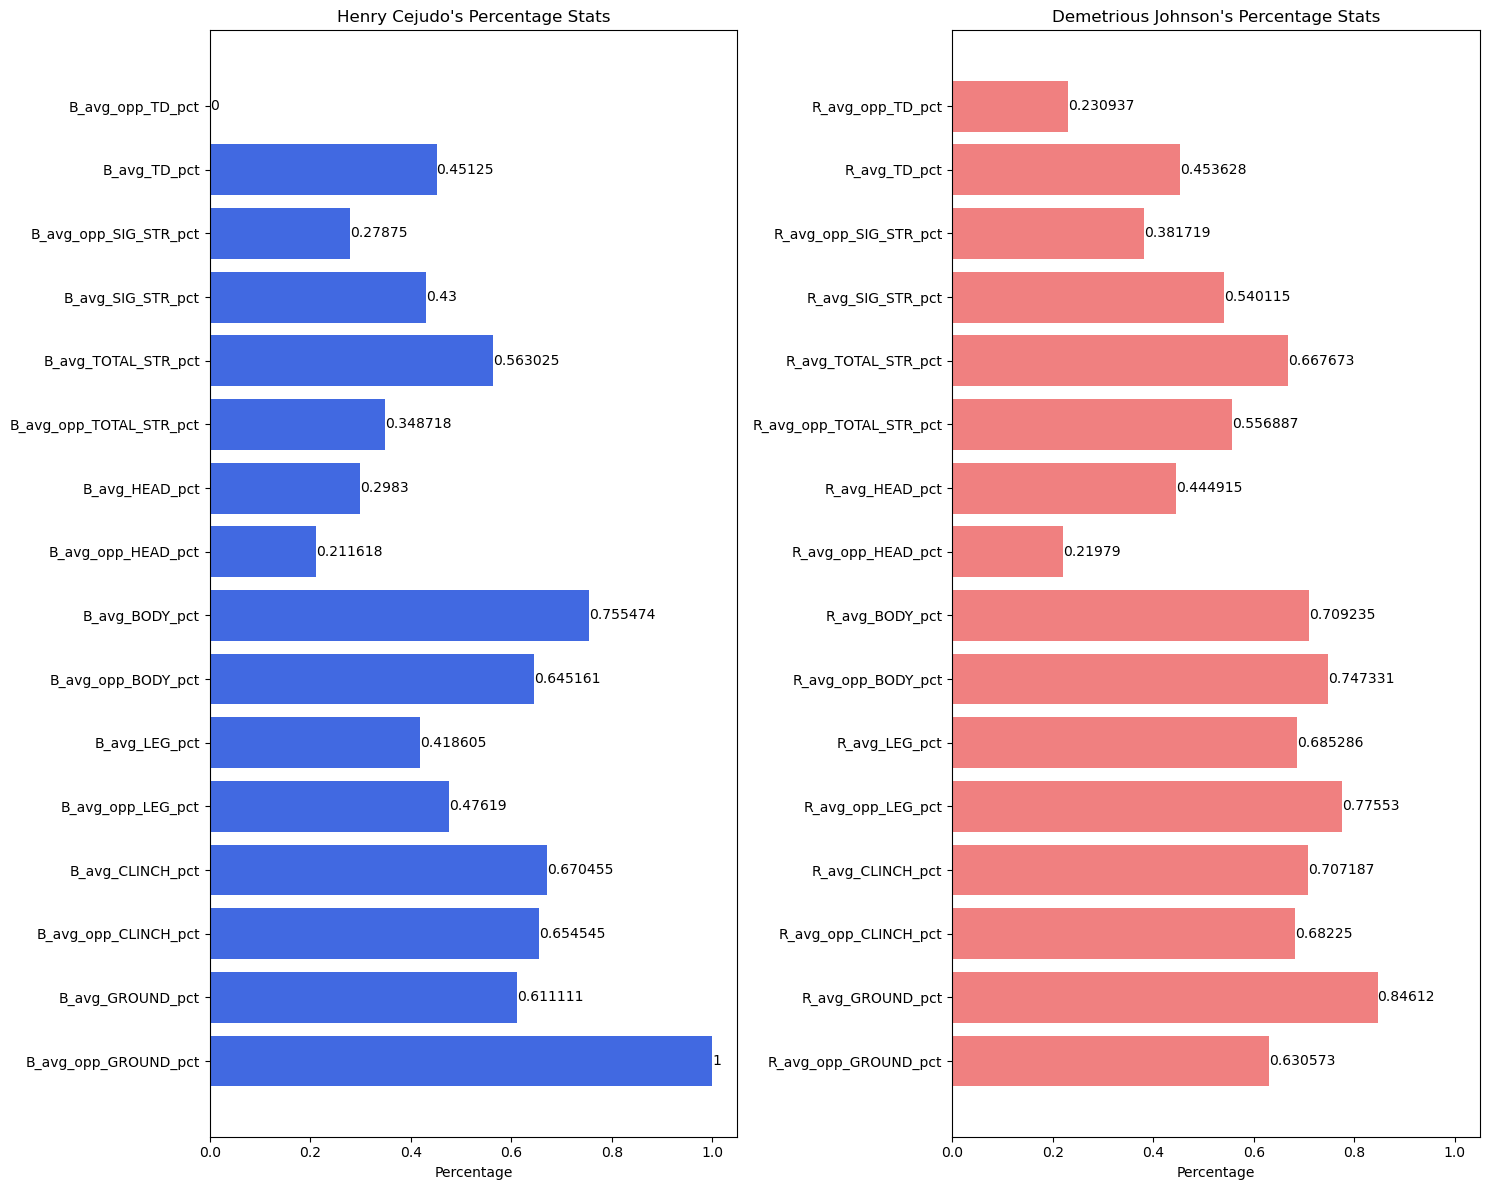

In [7]:
new_pct_cols_dj = DJ_HenryCejudo_df.loc["R_avg_opp_GROUND_pct":"R_avg_TOTAL_STR_pct"]
new_pct_cols_henry = DJ_HenryCejudo_df.loc["B_avg_opp_GROUND_pct":"B_avg_TOTAL_STR_pct"]

original_pct_cols_dj = DJ_HenryCejudo_df.loc["R_avg_SIG_STR_pct":"R_avg_opp_TD_pct"]
original_pct_cols_henry = DJ_HenryCejudo_df.loc["B_avg_SIG_STR_pct":"B_avg_opp_TD_pct"]

# showing the new accuracy/percent columns.
print(new_pct_cols_dj)
# showing the original accuracy/percent columns that the dataset already had for only takedowns and significant strikes.
print("\n", original_pct_cols_dj)


pct_cols_dj = pd.concat([new_pct_cols_dj, original_pct_cols_dj])
pct_cols_henry = pd.concat([new_pct_cols_henry, original_pct_cols_henry])
print("\n\n", pct_cols_dj)



fig_pct, axs_pct = plt.subplots(1, 2, sharex=True, figsize = (15, 12))

pct_graph1 = axs_pct[0].barh(pct_cols_henry.index, pct_cols_henry.values, color = "royalblue")
axs_pct[0].bar_label(pct_graph1)
axs_pct[0].set_xlabel("Percentage")
axs_pct[0].set_title("Henry Cejudo's Percentage Stats")

pct_graph1 = axs_pct[1].barh(pct_cols_dj.index, pct_cols_dj.values, color = "lightcoral")
axs_pct[1].bar_label(pct_graph1)
axs_pct[1].set_xlabel("Percentage")
axs_pct[1].set_title("Demetrious Johnson's Percentage Stats")

fig_pct.tight_layout()
plt.show()

Notes on Visualizations:
- Looking at the right bar plot, Demetrious Johnson has higher percentages in 6/8 aspects compared to his previous opponents (not compared to Henry Cejudo)
    * What this means -> DJ's takedowns, significant strikes, total strikes, significant strikes to the head, significant strikes in the clinch, and significant strikes on the ground were on average, more accurate compared to his past opponents 
    * avg_TD, avg_SIG_STR, avg_TOTAL_STR, avg_HEAD, avg_CLINCH, avg_GROUND
- For Henry Cejudo (left bar plot), 
    * as you can see, Henry Cejudo also has higher percentages in 6/8 aspects
    * avg_TD, avg_SIG_STR, avg_TOTAL_STR, avg_HEAD, avg_BODY, avg_CLINCH
- Comparing Demetrious Johnson to Henry Cejudo:
    * DJ has higher percentages than Henry Cejudo in 7/8 columns (only considering the columns without "opp")
    * DJ also has higher percentages than Henry Cejudo in 7/8 "opponent" columns (only considering the columns with "opp")
- Adding onto the previous theory:
    * I think that these visualizations also support the idea that DJ has an extremely aggressive fight style compared to other fighters
    * while his opponents are landing more attacks (compared to Henry's opponents), he is landing even more / defending more
- It may be difficult to say for sure but a trend to look out for when identifying skilled fighters may be to look at the stats percentages
    * if percentage > past opponents -> implies better offense/defense or both
- However, you can't only look at percentages because there could be a case where fighter A attempted 1 takedown and it was successful while fighter B attempted 100 takedowns. You don't want to confidently state that fighter A has more accurate takedowns than fighter B.
    * So, I think it would be a good idea to also look at the overall number
    * Maybe create new columns comparing each column to the mean of the columns.
    * For example, avg_TD_landed / mean(avg_TD_landed) = 1.2
    * This way you can instantly tell if the percentage is based on a small or large sample size.

In [8]:
print("Henry Cejudo's Wins/Losses: ", DJ_HenryCejudo_df["B_wins"], "|", DJ_HenryCejudo_df["B_losses"])
print("Demetrious Johnson's Wins/Losses: ", DJ_HenryCejudo_df["R_wins"], "|", DJ_HenryCejudo_df["R_losses"])

Henry Cejudo's Wins/Losses:  4 | 0
Demetrious Johnson's Wins/Losses:  11 | 2


In [9]:
# Creating new columns that divide each col by its combined mean.
# For example, B_avg_KD and R_avg_KD would be divided by the combined mean. 
# This would lead to 2 more cols to be created called B_avg_KD_div_mean and R_avg_KD_div_mean.
B_fighter_df = new_df.loc[:, "B_avg_KD":"B_avg_opp_CTRL_time(seconds)"]
R_fighter_df = new_df.loc[:, "R_avg_KD":"R_avg_opp_CTRL_time(seconds)"]


# Creating dictionary to save the new columns.
new_mean_cols = {}
# Looping through the original column names.
for col in B_fighter_df.columns.to_list():
    # combining B and R fighter column values to get the combined mean.
    combined_col = pd.concat([new_df[col], new_df["R" + col[1:]]]).copy()

    # creating the new column for fighter B by dividing original col by combined col mean.
    new_mean_cols[col + "_div_mean"] = new_df[col] / combined_col.mean()
    # creating new column for fighter R.
    new_mean_cols["R" + col[1:] + "_div_mean"] = new_df["R" + col[1:]] / combined_col.mean()

mean_df = pd.DataFrame(new_mean_cols)
new_mean_df = pd.concat([new_df, mean_df], axis=1)
display(new_mean_df)



# Creating the percentage cols for every single fight that were shown earlier (for the Demetrious Johnson and Henry Cejudo fight).
new_mean_df["R_avg_opp_GROUND_pct"] = new_mean_df["R_avg_opp_GROUND_landed"] / new_mean_df["R_avg_opp_GROUND_att"] # R_avg_opp_GROUND
new_mean_df["R_avg_GROUND_pct"] = new_mean_df["R_avg_GROUND_landed"] / new_mean_df["R_avg_GROUND_att"] # R_avg_GROUND

new_mean_df["R_avg_opp_CLINCH_pct"] = new_mean_df["R_avg_opp_CLINCH_landed"] / new_mean_df["R_avg_opp_CLINCH_att"] # R_avg_opp_CLINCH
new_mean_df["R_avg_CLINCH_pct"] = new_mean_df["R_avg_CLINCH_landed"] / new_mean_df["R_avg_CLINCH_att"] # R_avg_CLINCH

new_mean_df["R_avg_opp_LEG_pct"] = new_mean_df["R_avg_opp_LEG_landed"] / new_mean_df["R_avg_opp_LEG_att"] # R_avg_opp_LEG
new_mean_df["R_avg_LEG_pct"] = new_mean_df["R_avg_LEG_landed"] / new_mean_df["R_avg_LEG_att"] # R_avg_LEG

new_mean_df["R_avg_opp_BODY_pct"] = new_mean_df["R_avg_opp_BODY_landed"] / new_mean_df["R_avg_opp_BODY_att"] # R_avg_opp_BODY
new_mean_df["R_avg_BODY_pct"] = new_mean_df["R_avg_BODY_landed"] / new_mean_df["R_avg_BODY_att"] # R_avg_BODY

new_mean_df["R_avg_opp_HEAD_pct"] = new_mean_df["R_avg_opp_HEAD_landed"] / new_mean_df["R_avg_opp_HEAD_att"] # R_avg_opp_HEAD
new_mean_df["R_avg_HEAD_pct"] = new_mean_df["R_avg_HEAD_landed"] / new_mean_df["R_avg_HEAD_att"] # R_avg_HEAD

new_mean_df["R_avg_opp_TOTAL_STR_pct"] = new_mean_df["R_avg_opp_TOTAL_STR_landed"] / new_mean_df["R_avg_opp_TOTAL_STR_att"] # R_avg_opp_TOTAL_STR
new_mean_df["R_avg_TOTAL_STR_pct"] = new_mean_df["R_avg_TOTAL_STR_landed"] / new_mean_df["R_avg_TOTAL_STR_att"] # R_avg_TOTAL_STR



new_mean_df["B_avg_opp_GROUND_pct"] = new_mean_df["B_avg_opp_GROUND_landed"] / new_mean_df["B_avg_opp_GROUND_att"] # B_avg_opp_GROUND
new_mean_df["B_avg_GROUND_pct"] = new_mean_df["B_avg_GROUND_landed"] / new_mean_df["B_avg_GROUND_att"] # B_avg_GROUND

new_mean_df["B_avg_opp_CLINCH_pct"] = new_mean_df["B_avg_opp_CLINCH_landed"] / new_mean_df["B_avg_opp_CLINCH_att"] # B_avg_opp_CLINCH
new_mean_df["B_avg_CLINCH_pct"] = new_mean_df["B_avg_CLINCH_landed"] / new_mean_df["B_avg_CLINCH_att"] # B_avg_CLINCH

new_mean_df["B_avg_opp_LEG_pct"] = new_mean_df["B_avg_opp_LEG_landed"] / new_mean_df["B_avg_opp_LEG_att"] # B_avg_opp_LEG
new_mean_df["B_avg_LEG_pct"] = new_mean_df["B_avg_LEG_landed"] / new_mean_df["B_avg_LEG_att"] # B_avg_LEG

new_mean_df["B_avg_opp_BODY_pct"] = new_mean_df["B_avg_opp_BODY_landed"] / new_mean_df["B_avg_opp_BODY_att"] # B_avg_opp_BODY
new_mean_df["B_avg_BODY_pct"] = new_mean_df["B_avg_BODY_landed"] / new_mean_df["B_avg_BODY_att"] # B_avg_BODY

new_mean_df["B_avg_opp_HEAD_pct"] = new_mean_df["B_avg_opp_HEAD_landed"] / new_mean_df["B_avg_opp_HEAD_att"] # B_avg_opp_HEAD
new_mean_df["B_avg_HEAD_pct"] = new_mean_df["B_avg_HEAD_landed"] / new_mean_df["B_avg_HEAD_att"] # B_avg_HEAD

new_mean_df["B_avg_opp_TOTAL_STR_pct"] = new_mean_df["B_avg_opp_TOTAL_STR_landed"] /new_mean_df["B_avg_opp_TOTAL_STR_att"] # B_avg_opp_TOTAL_STR
new_mean_df["B_avg_TOTAL_STR_pct"] = new_mean_df["B_avg_TOTAL_STR_landed"] / new_mean_df["B_avg_TOTAL_STR_att"] # B_avg_TOTAL_STR



new_mean_df.info(verbose=True)

,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,...,B_avg_GROUND_landed_div_mean,R_avg_GROUND_landed_div_mean,B_avg_opp_GROUND_att_div_mean,R_avg_opp_GROUND_att_div_mean,B_avg_opp_GROUND_landed_div_mean,R_avg_opp_GROUND_landed_div_mean,B_avg_CTRL_time(seconds)_div_mean,R_avg_CTRL_time(seconds)_div_mean,B_avg_opp_CTRL_time(seconds)_div_mean,R_avg_opp_CTRL_time(seconds)_div_mean
0,Adrian Yanez,Gustavo Lopez,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Bantamweight,0.000000,0.000,...,0.508146,0.000000,5.457554,0.000000,5.437018,0.000000,0.234074,0.034423,2.190640,0.426287
1,Trevin Giles,Roman Dolidze,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Middleweight,0.500000,0.000,...,0.762219,1.535024,0.224283,0.126159,0.110960,0.076285,1.511152,1.212751,0.193408,1.221134
4,Marion Reneau,Macy Chiasson,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenBantamweight,0.125000,0.000,...,3.070047,0.420808,0.784991,0.989999,0.832197,0.891144,2.686684,0.972680,1.233962,2.448405
5,Leonardo Santos,Grant Dawson,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,Lightweight,0.000000,0.000,...,1.545610,1.377551,0.355115,1.077026,0.471578,0.802723,2.972391,0.406402,0.137162,1.527898
6,Song Kenan,Max Griffin,Keith Peterson,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,Welterweight,0.046875,0.125,...,0.078074,0.264659,0.131708,0.121487,0.158204,0.124829,1.022405,0.092941,0.632307,0.729720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5759,Tito Ortiz,Evan Tanner,John McCarthy,2001-02-23,"Atlantic City, New Jersey, USA",Red,True,LightHeavyweight,0.000000,0.000,...,2.879493,2.890079,0.598088,0.098124,0.332879,0.145634,0.864007,3.129874,0.000000,0.030590
5767,Chuck Liddell,Jeff Monson,Mario Yamasaki,2000-12-16,"Tokyo, Japan",Red,False,Middleweight,0.000000,0.000,...,4.742694,0.889255,1.046654,0.037381,0.887676,0.055480,2.912152,0.426840,0.765737,0.157884
5799,Tito Ortiz,Wanderlei Silva,John McCarthy,2000-04-14,"Tokyo, Japan",Red,True,LightHeavyweight,0.500000,0.500,...,0.084691,3.091220,0.000000,0.392495,0.000000,0.582538,0.000000,3.273589,0.000000,0.051312
5840,Jeremy Horn,Chuck Liddell,John McCarthy,1999-03-05,"Bay St. Louis, Mississippi, USA",Red,False,Middleweight,0.000000,0.000,...,0.846910,0.846910,0.149522,0.897132,0.221919,1.109596,0.000000,0.000000,0.000000,0.000000


<class 'pandas.core.frame.DataFrame'>
Index: 3890 entries, 0 to 5884
Data columns (total 264 columns):
 #    Column                                 Dtype         
---   ------                                 -----         
 0    R_fighter                              object        
 1    B_fighter                              object        
 2    Referee                                object        
 3    date                                   datetime64[ns]
 4    location                               object        
 5    Winner                                 object        
 6    title_bout                             bool          
 7    weight_class                           object        
 8    B_avg_KD                               float64       
 9    B_avg_opp_KD                           float64       
 10   B_avg_SIG_STR_pct                      float64       
 11   B_avg_opp_SIG_STR_pct                  float64       
 12   B_avg_TD_pct                           float64     

Since all of these new columns were created, lets go back and check the stats of Demetrious Johnson and Henry Cejudo compared to the mean of all other fighters.

R_fighter                      Demetrious Johnson
B_fighter                            Henry Cejudo
Referee                             John McCarthy
date                          2016-04-23 00:00:00
location                   Las Vegas, Nevada, USA
                                    ...          
B_avg_BODY_pct                           0.755474
B_avg_opp_HEAD_pct                       0.211618
B_avg_HEAD_pct                             0.2983
B_avg_opp_TOTAL_STR_pct                  0.348718
B_avg_TOTAL_STR_pct                      0.563025
Name: 2382, Length: 264, dtype: object

Index(['B_avg_BODY_att_div_mean', 'B_avg_BODY_landed_div_mean',
       'B_avg_CLINCH_att_div_mean', 'B_avg_CLINCH_landed_div_mean',
       'B_avg_CTRL_time(seconds)_div_mean', 'B_avg_DISTANCE_att_div_mean',
       'B_avg_DISTANCE_landed_div_mean', 'B_avg_GROUND_att_div_mean',
       'B_avg_GROUND_landed_div_mean', 'B_avg_HEAD_att_div_mean',
       'B_avg_HEAD_landed_div_mean', 'B_avg_KD_div_mean',
       'B_avg_LEG_att_div_mean', 'B_avg_LEG_landed_div_mean',
       'B_avg_REV_div_mean', 'B_avg_SIG_STR_att_div_mean',
       'B_avg_SIG_STR_landed_div_mean', 'B_avg_SIG_STR_pct_div_mean',
       'B_avg_SUB_ATT_div_mean', 'B_avg_TD_att_div_mean',
       'B_avg_TD_landed_div_mean', 'B_avg_TD_pct_div_mean',
       'B_avg_TOTAL_STR_att_div_mean', 'B_avg_TOTAL_STR_landed_div_mean',
       'B_avg_opp_BODY_att_div_mean', 'B_avg_opp_BODY_landed_div_mean',
       'B_avg_opp_CLINCH_att_div_mean', 'B_avg_opp_CLINCH_landed_div_mean',
       'B_avg_opp_CTRL_time(seconds)_div_mean',
       'B_avg_opp_DI

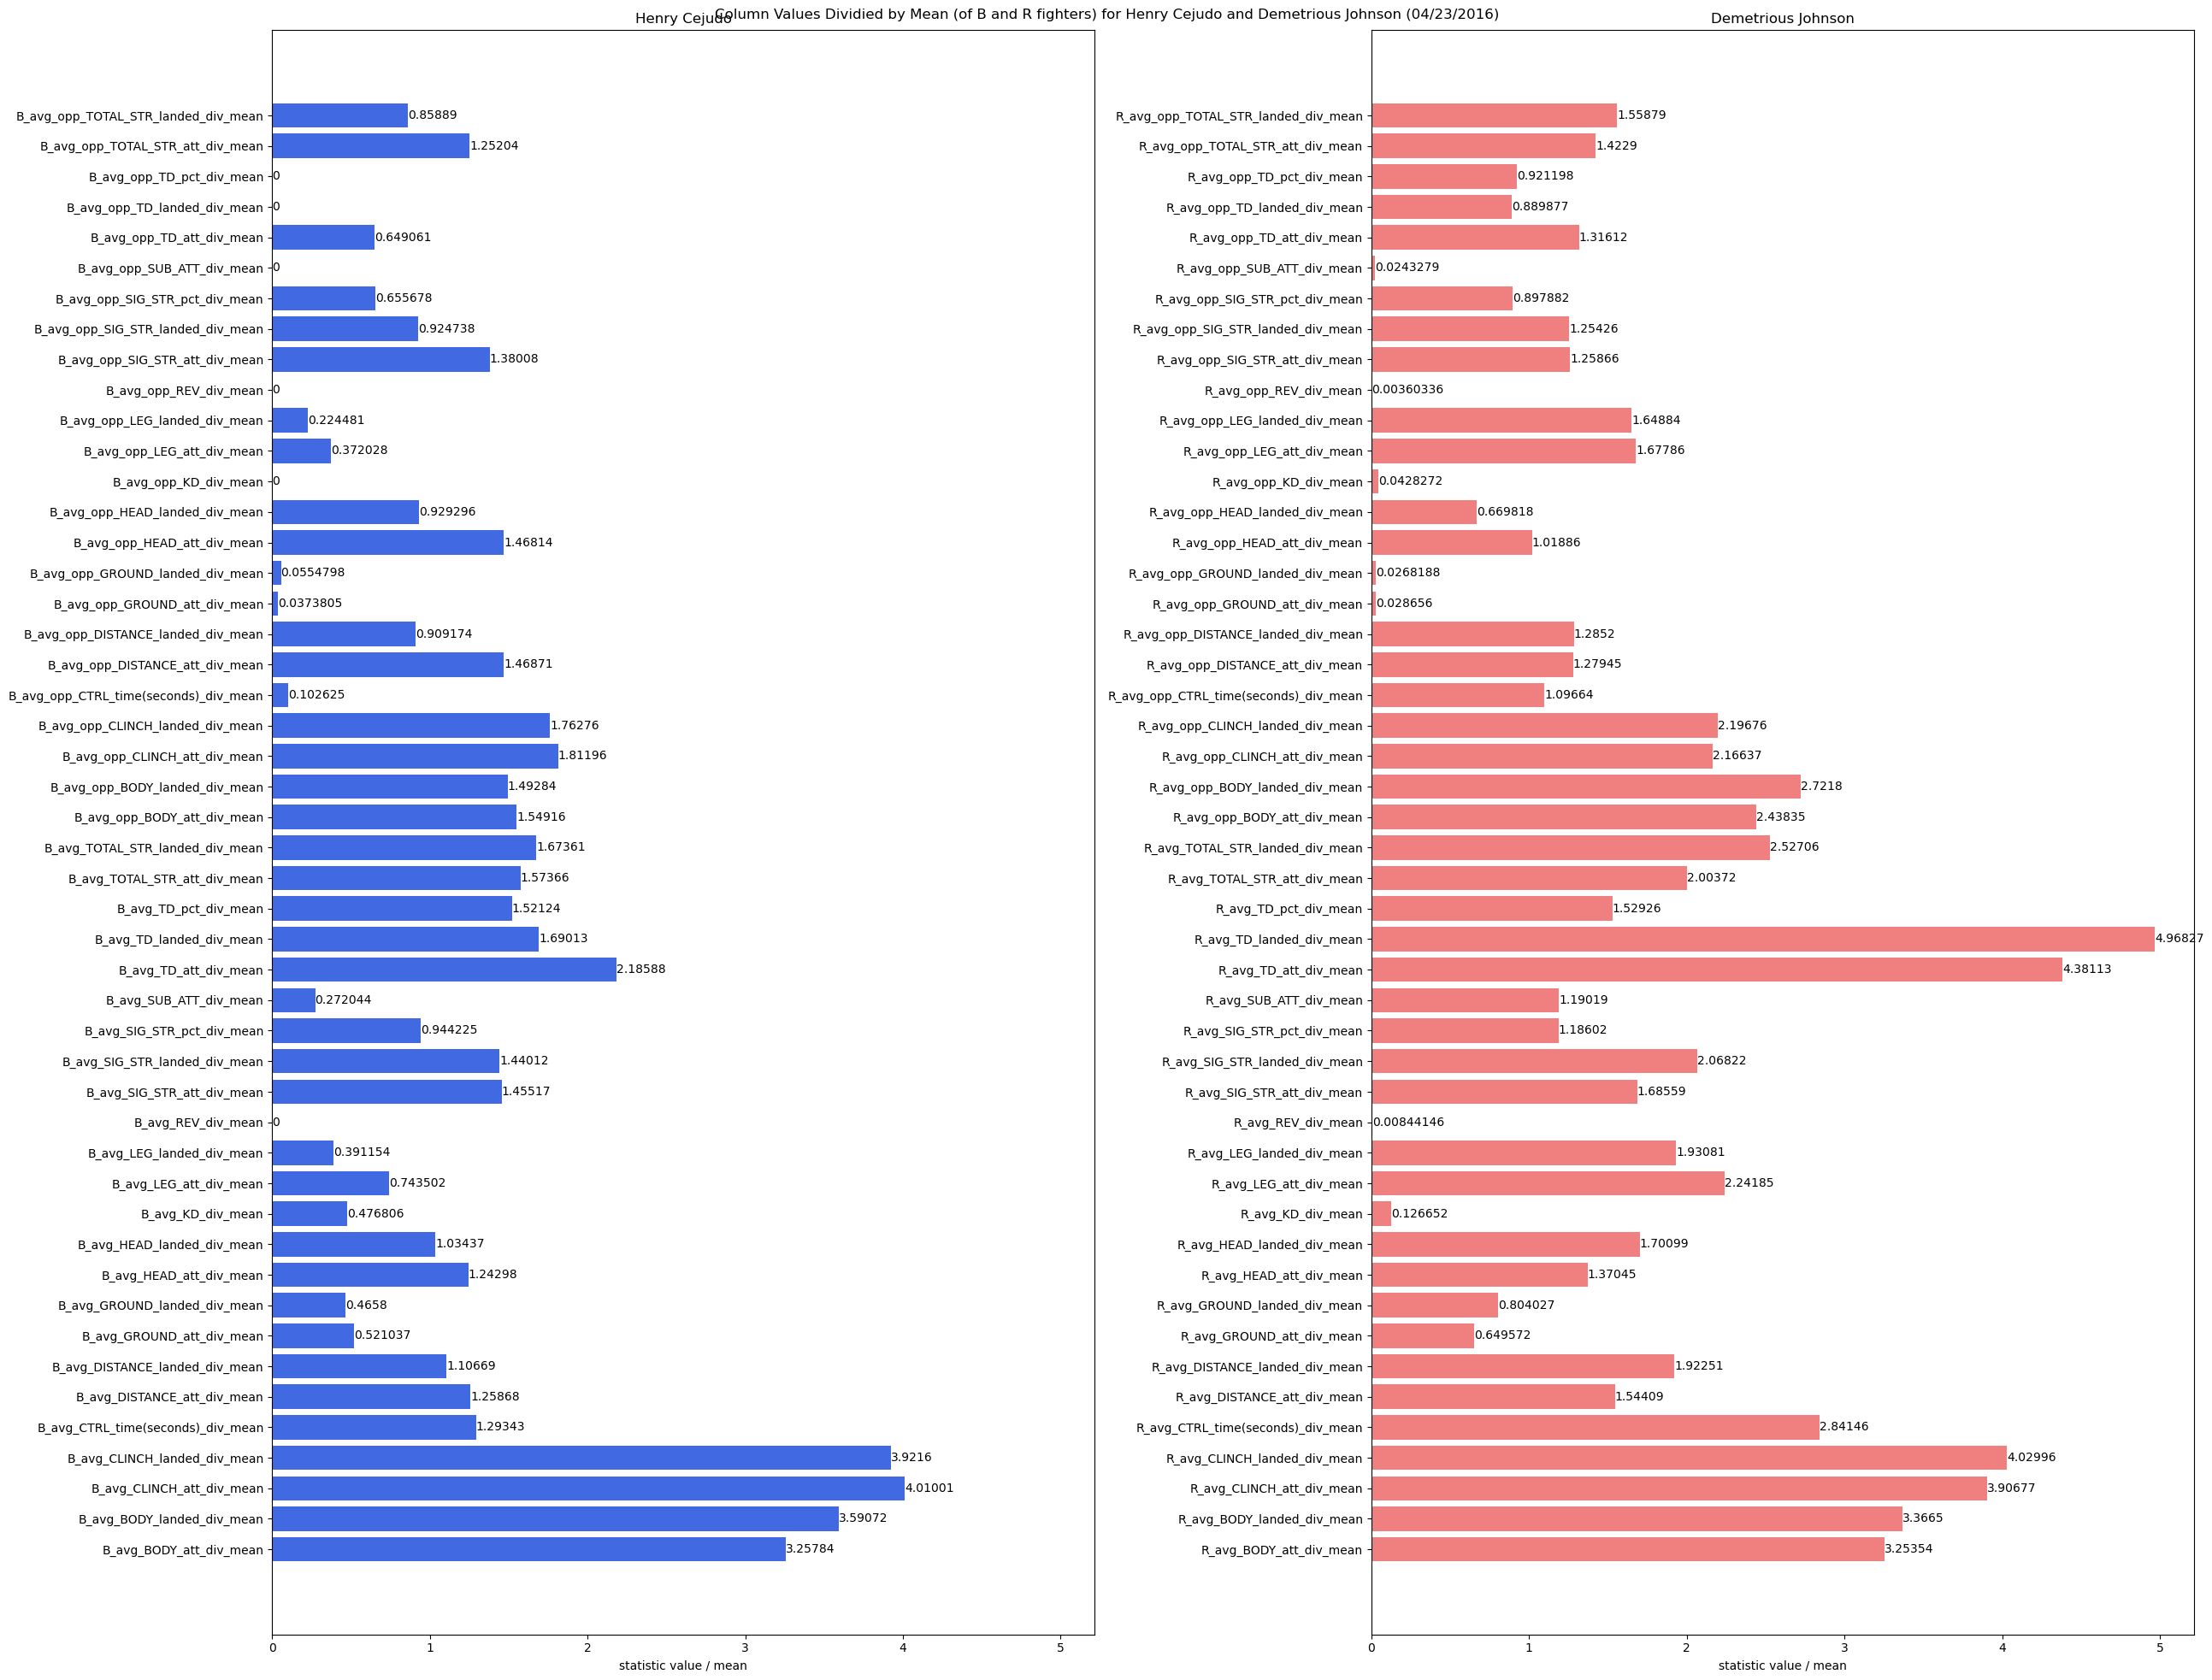

In [10]:
# Only getting Demetrious Johnson's fights
new_dj_df = new_mean_df.loc[(new_mean_df["B_fighter"] == "Demetrious Johnson") | (new_mean_df["R_fighter"] == "Demetrious Johnson")]

# 4th row = Demetrious Johnson vs Henry Cejudo
new_dj_henry_df = new_dj_df.iloc[4]
display(new_dj_henry_df)

# getting all of the new columns only and sorting them by name.
# Sorting by col name allows all of fighter B's statistics to be next to each other and also for fighter R.
new_dj_henry_mean_index = new_dj_henry_df.loc["B_avg_KD_div_mean":"R_avg_opp_CTRL_time(seconds)_div_mean"].sort_index()
print(new_dj_henry_mean_index.index)



fig_mean, axs_mean = plt.subplots(1, 2, sharex=True, figsize = (26,20))

# Bar plot showing all of Henry Cejudo's new statistics.
mean_graph1 = axs_mean[0].barh(new_dj_henry_mean_index.loc["B_avg_BODY_att_div_mean":"B_avg_opp_TOTAL_STR_landed_div_mean"].index,
                               new_dj_henry_mean_index.loc["B_avg_BODY_att_div_mean":"B_avg_opp_TOTAL_STR_landed_div_mean"].values,
                               color = "royalblue")
axs_mean[0].bar_label(mean_graph1)
axs_mean[0].set_xlabel("statistic value / mean")
axs_mean[0].set_title("Henry Cejudo")

# Bar plot showing all of Demetrious Johnson's new statistics.
mean_graph2 = axs_mean[1].barh(new_dj_henry_mean_index.loc["R_avg_BODY_att_div_mean":"R_avg_opp_TOTAL_STR_landed_div_mean"].index,
                               new_dj_henry_mean_index.loc["R_avg_BODY_att_div_mean":"R_avg_opp_TOTAL_STR_landed_div_mean"].values,
                               color = "lightcoral")
axs_mean[1].bar_label(mean_graph2)
axs_mean[1].set_xlabel("statistic value / mean")
axs_mean[1].set_title("Demetrious Johnson")


fig_mean.suptitle("Column Values Dividied by Mean (of B and R fighters) for Henry Cejudo and Demetrious Johnson (04/23/2016)")

fig_mean.tight_layout()
plt.show()

In [11]:
# Double check if the columns for both graphs are in the same order.
order_check_replace_R = new_dj_henry_mean_index.loc["R_avg_BODY_att_div_mean":"R_avg_opp_TOTAL_STR_landed_div_mean"].index.str.removeprefix("R_")
order_check_replace_B = new_dj_henry_mean_index.loc["B_avg_BODY_att_div_mean":"B_avg_opp_TOTAL_STR_landed_div_mean"].index.str.removeprefix("B_")
# print(order_check_replace_R)
# print(order_check_replace_B)

if order_check_replace_B.tolist() == order_check_replace_R.tolist():
    print("Order of columns are the same.")
else:
    print("Order not the same.")

Order of columns are the same.


Notes on Visualization Above:
- I think there are too many columns to properly compare the values
- Probably is a better idea to split the columns to compare the opponents columns and the fighters columns

['R_fighter', 'B_fighter', 'Referee', 'date', 'location', 'Winner', 'title_bout', 'weight_class', 'B_avg_KD', 'B_avg_SIG_STR_pct', 'B_avg_TD_pct', 'B_avg_SUB_ATT', 'B_avg_REV', 'B_avg_SIG_STR_att', 'B_avg_SIG_STR_landed', 'B_avg_TOTAL_STR_att', 'B_avg_TOTAL_STR_landed', 'B_avg_TD_att', 'B_avg_TD_landed', 'B_avg_HEAD_att', 'B_avg_HEAD_landed', 'B_avg_BODY_att', 'B_avg_BODY_landed', 'B_avg_LEG_att', 'B_avg_LEG_landed', 'B_avg_DISTANCE_att', 'B_avg_DISTANCE_landed', 'B_avg_CLINCH_att', 'B_avg_CLINCH_landed', 'B_avg_GROUND_att', 'B_avg_GROUND_landed', 'B_avg_CTRL_time(seconds)', 'B_total_time_fought(seconds)', 'B_total_rounds_fought', 'B_total_title_bouts', 'B_current_win_streak', 'B_current_lose_streak', 'B_longest_win_streak', 'B_wins', 'B_losses', 'B_draw', 'B_win_by_Decision_Majority', 'B_win_by_Decision_Split', 'B_win_by_Decision_Unanimous', 'B_win_by_KO/TKO', 'B_win_by_Submission', 'B_Stance', 'B_Height_cms', 'B_Reach_cms', 'B_Weight_lbs', 'R_avg_KD', 'R_avg_SIG_STR_pct', 'R_avg_TD_p

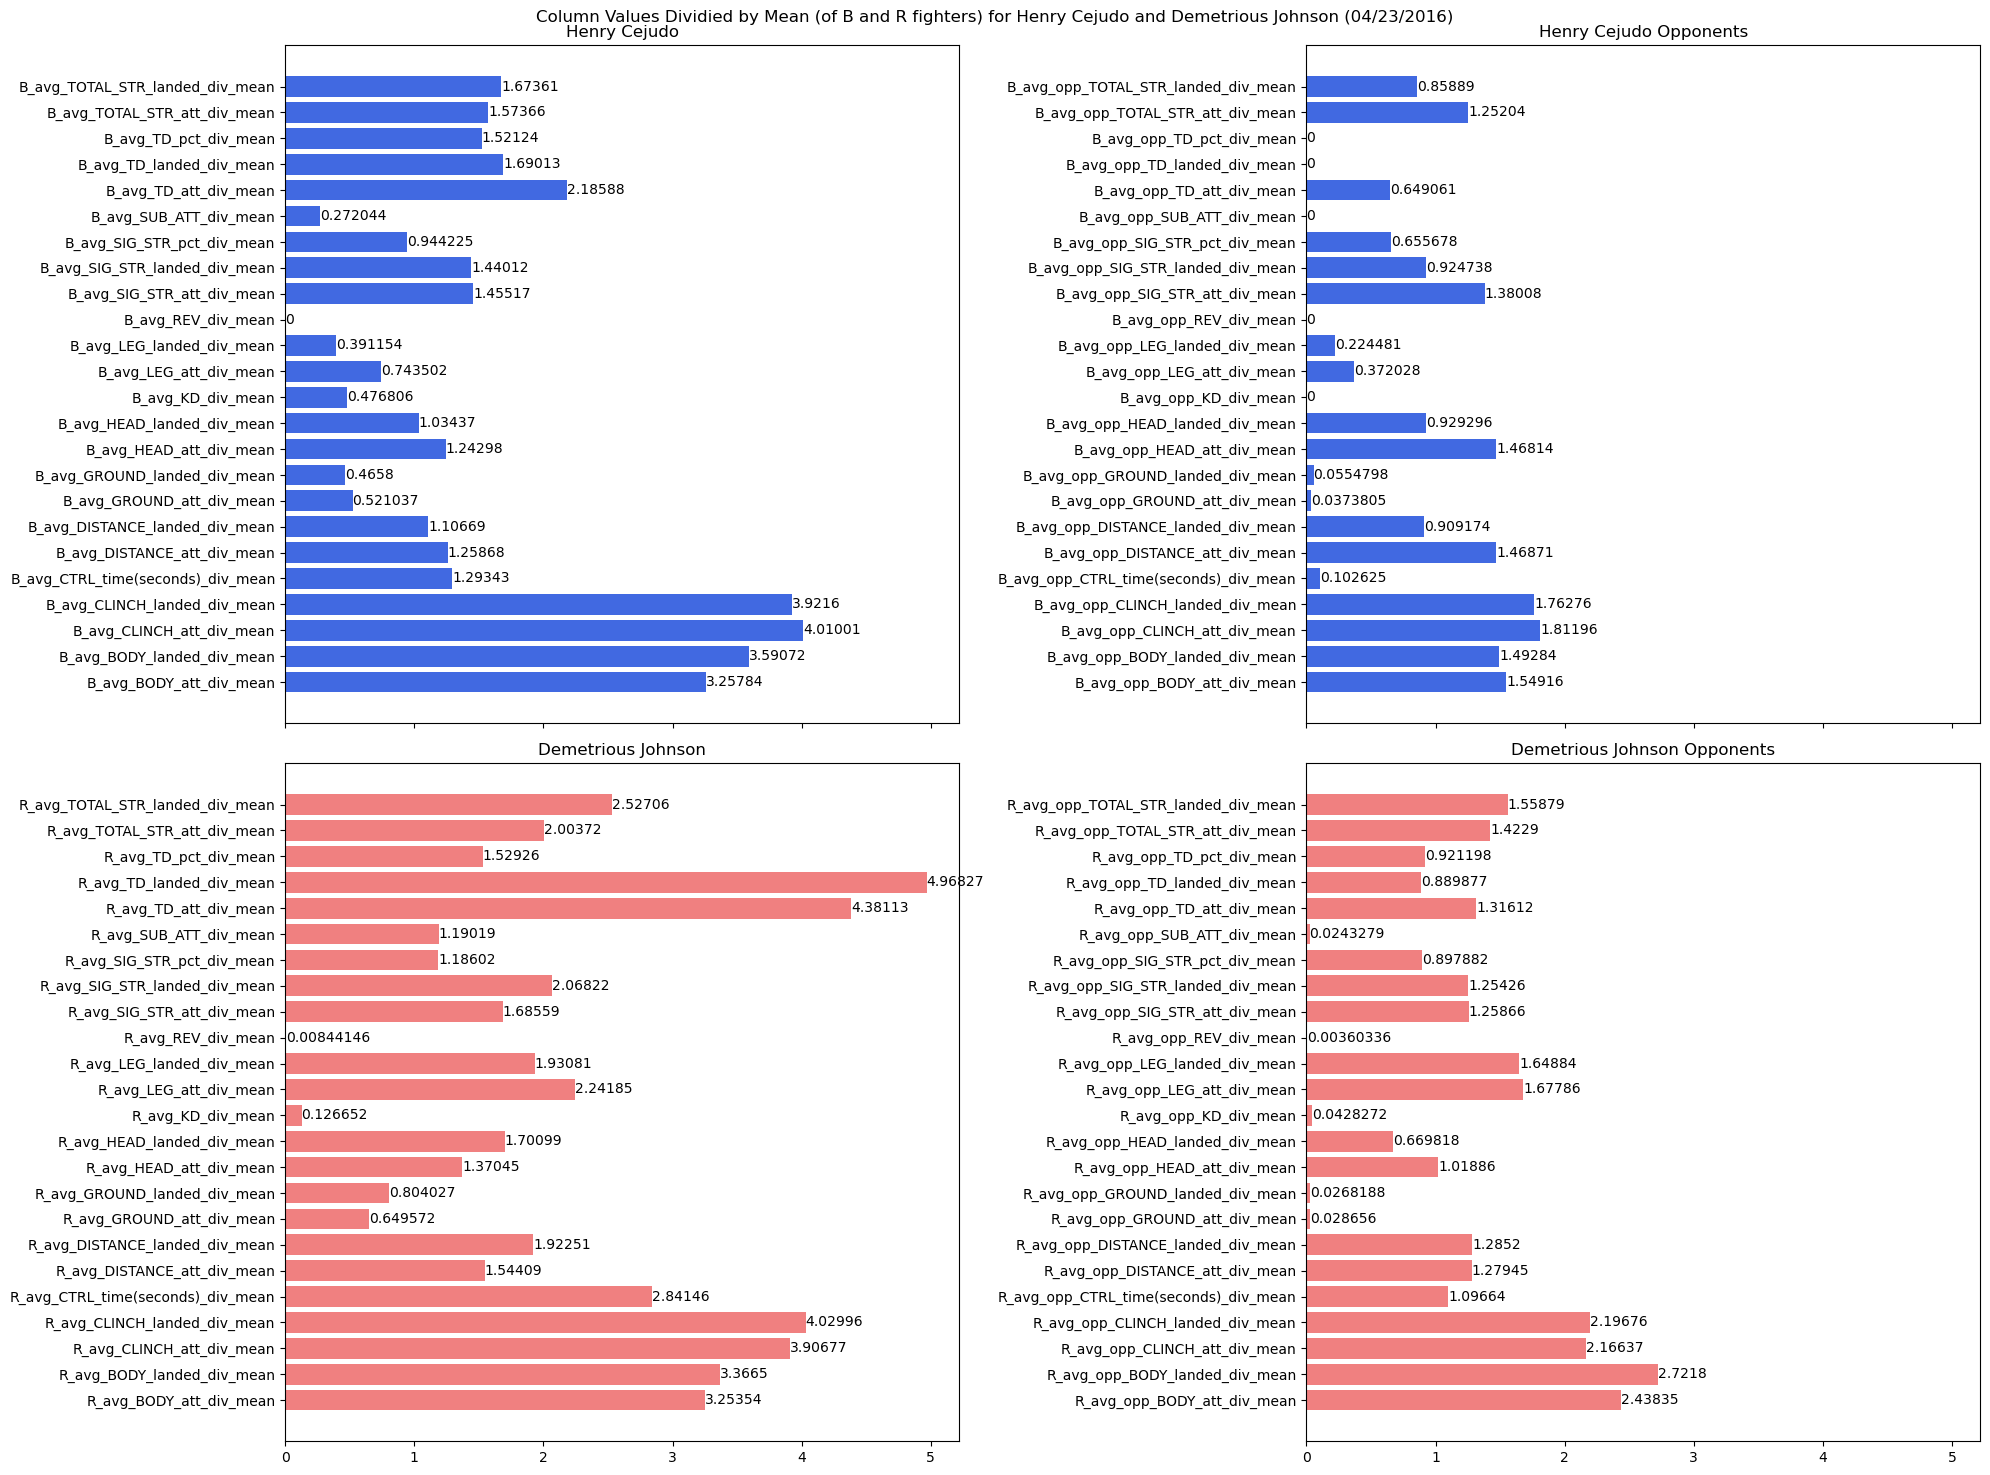

In [12]:
# This creates a series that contains all of the columns/values for the fighters (DJ and Henry Cejudo in this case).
new_dj_henry_mean_individual_index = new_dj_henry_df.loc[~new_dj_henry_df.index.str.contains("opp")]
print(new_dj_henry_mean_individual_index.index.tolist())
new_dj_henry_mean_individual_index = new_dj_henry_mean_individual_index.loc["B_avg_KD_div_mean":"R_avg_CTRL_time(seconds)_div_mean"].sort_index()
print("\n", new_dj_henry_mean_individual_index)

# This creates a series for all opponents.
new_dj_henry_mean_opp_index = new_dj_henry_df.loc[new_dj_henry_df.index.str.contains("opp")]
print("\n", new_dj_henry_mean_opp_index.index.tolist())
new_dj_henry_mean_opp_index = new_dj_henry_mean_opp_index.loc["B_avg_opp_KD_div_mean":"R_avg_opp_CTRL_time(seconds)_div_mean"].sort_index()
print("\n", new_dj_henry_mean_opp_index)


fig_sep, axs_sep = plt.subplots(2, 2, sharex=True, figsize = (20, 15))

individual_graph1 = axs_sep[0,0].barh(new_dj_henry_mean_individual_index.loc["B_avg_BODY_att_div_mean":"B_avg_TOTAL_STR_landed_div_mean"].index,
                                      new_dj_henry_mean_individual_index.loc["B_avg_BODY_att_div_mean":"B_avg_TOTAL_STR_landed_div_mean"].values,
                                      color = "royalblue")
axs_sep[0,0].bar_label(individual_graph1)
axs_sep[0,0].set_title("Henry Cejudo")

individual_graph2 = axs_sep[0,1].barh(new_dj_henry_mean_opp_index.loc["B_avg_opp_BODY_att_div_mean":"B_avg_opp_TOTAL_STR_landed_div_mean"].index,
                                      new_dj_henry_mean_opp_index.loc["B_avg_opp_BODY_att_div_mean":"B_avg_opp_TOTAL_STR_landed_div_mean"].values,
                                      color = "royalblue")
axs_sep[0,1].bar_label(individual_graph2)
axs_sep[0,1].set_title("Henry Cejudo Opponents")

individual_graph3 = axs_sep[1,0].barh(new_dj_henry_mean_individual_index.loc["R_avg_BODY_att_div_mean":"R_avg_TOTAL_STR_landed_div_mean"].index,
                                      new_dj_henry_mean_individual_index.loc["R_avg_BODY_att_div_mean":"R_avg_TOTAL_STR_landed_div_mean"].values,
                                      color = "lightcoral")
axs_sep[1,0].bar_label(individual_graph3)
axs_sep[1,0].set_title("Demetrious Johnson")

individual_graph4 = axs_sep[1,1].barh(new_dj_henry_mean_opp_index.loc["R_avg_opp_BODY_att_div_mean":"R_avg_opp_TOTAL_STR_landed_div_mean"].index,
                                      new_dj_henry_mean_opp_index.loc["R_avg_opp_BODY_att_div_mean":"R_avg_opp_TOTAL_STR_landed_div_mean"].values,
                                      color = "lightcoral")
axs_sep[1,1].bar_label(individual_graph4)
axs_sep[1,1].set_title("Demetrious Johnson Opponents")

fig_sep.suptitle("Column Values Dividied by Mean (of B and R fighters) for Henry Cejudo and Demetrious Johnson (04/23/2016)")
fig_sep.tight_layout()
plt.show()

In [13]:
# Just to make sure if the order of the columns are the same for the opponent and individual data.
# Conclude: Because nothing is printed in the output, it can be concluded that the order is the same for the series above.

# Removing '_opp' to see if the 2 series have the same order of columns.
new_dj_henry_without_opp = new_dj_henry_mean_opp_index.index.str.replace("_opp", "", regex=False)


for col in range(len(new_dj_henry_without_opp.to_list())):
    if new_dj_henry_without_opp.to_list()[col] == new_dj_henry_mean_individual_index.index.to_list()[col]:
        continue
    else:
        print("Not in the same order.")
        break

if new_dj_henry_without_opp.tolist() == new_dj_henry_mean_individual_index.index.tolist():
    print("Columns are in the same order.")

Columns are in the same order.


Notes on Visualization Above:
* Demetrious Johnson Individual Stats: 20/24 cols > 1.0 
* Demetrious Johnson Opponent Stats: 15/24 cols > 1.0
* Henry Cejudo Individual Stats: 16/24 cols > 1.0
* Henry Cejudo Opponent Stats: 8/24 cols > 1.0

Next Step:
* When I reached this part of the data analysis, I realized I was a little bit confused on what I was looking for.
* Understood that the initial question was too general which led to a lot of data analysis that couldn't lead to an exact answer.
* Old Question: How to identify a great fighter / How to identify if a fighter will become a skilled fighter.
* New Question: What aspects differ between fighters that have been UFC champions and fighters that have not? 
    * If there are aspects that have a clear difference, do those columns have a significant relationship to winning a UFC fight?

# New question analysis is in "NewQuestion.ipynb"